Obbiettivo è trasofrmare le transazioni del del dataset creditcard.csv in un grafo dove: noti= utenti, archi= transazioni.

In [4]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# 1. Caricamento dati
df = pd.read_csv('../data/creditcard.csv')

# 2. Creazione del Grafo
G = nx.Graph()

# Prendiamo un campione di 100 righe per non appesantire la prima visualizzazione
sample_df = df.head(100)

#
for index, row in sample_df.iterrows():
    # Creiamo un arco tra l'indice della transazione e una feature identificativa
    G.add_edge(row.name, "Transaction_Cluster_1") 

print(f"Grafo creato con {G.number_of_nodes()} nodi e {G.number_of_edges()} archi.")

Grafo creato con 101 nodi e 100 archi.


In [ ]:
#visiata del dataset, colonne e prime 5 righe
print(df.columns)
print(df.head())

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676

In [ ]:
#Fase 1: Costruzione grafo similarità tra transaizoni.
# usiamo NearestNeighbors di Scikit-Learn per trovare le connessioni (trovare i vicini di un nodo) 
# e NetworkX per creare il grafo.

import pandas as pd
import numpy as np
import networkx as nx
from sklearn.neighbors import NearestNeighbors #importa l’algoritmo KNN  da Scikit-Learn, per trovare i vicini di ogni punto.
from sklearn.preprocessing import StandardScaler # importa lo scaler per standardizzare le feature (media 0, varianza 1)

# 1. Pre-processing rapido (Fondamentale per KNN)

# Selezioniamo solo le feature V1-V28 e Amount
features = [c for c in df.columns if c not in ['Time', 'Class']] # crea lista feature= [v1,...,v28,'amount']
X = df[features].head(5000) # prende 5000 righe dentro df filtrando le colonne in feautre.
y = df['Class'].head(5000) #prende la colonna class e 5000 righe.

# Scaliamo i dati: KNN soffre se le scale sono diverse (es. Amount vs V1)
n_neighbors = 5 #voglio 5 vicini per ogni punto.
knn = NearestNeighbors(n_neighbors=n_neighbors + 1) # +1 perché il primo vicino è se stesso
knn.fit(X_scaled) #memorizza i dati in

distances, indices = knn.kneighbors(X_scaled) #indices restituisce una matrice. riga-i= punto del dataset, col-j= j-imo vicino del nodo
#per ciascuna riga (nodo) di X_scaled calcola i n_neighbors + 1 punti più vicini. 


# distances[i]:= array delle distanze tra il punto i e i suoi vicini.
# indices[i]: array degli indici (posizioni nelle righe di X_scaled) dei vicini di i.

# 3. Trasformazione in Grafo Pesato
G = nx.Graph() 

# aggiunta degli archi con i pesi
for i in range(len(indices)): #i= nodo=riga di X_scaled
    for j in range(1, n_neighbors + 1): # Saltiamo il primo (se stesso)
        neighbor_idx = indices[i][j] #indice del nodo vicino (cera un nodo- il j-ismo vicino del nodo i)
        distance = distances[i][j] # prende la distanza tra i e quel vicino.
        weight = 1 / (1 + distance)  # peso dell'arco. peso= 1/distanza
        G.add_edge(i, neighbor_idx, weight=weight)

print(f"✅ Grafo creato: {G.number_of_nodes()} nodi e {G.number_of_edges()} archi.")

✅ Grafo creato: 5000 nodi e 18392 archi.


In [10]:
#test_metrica per rilevamento frodi.

# Calcoliamo il PageRank (importanza del nodo nel network)
pagerank = nx.pagerank(G, weight='weight')

# Creiamo un DataFrame: prima colonna= node_index= lista dei nodi; seconda colonnna= page_rank_score = lista dei punteggi, colonna delle etichette Class = is_fraud = 0 (frode), 1(normale)
# ho creato un dataframe con 2 colonne, quella dei nodi e quella dei punnteggi associati
analysis_df = pd.DataFrame({
    'node_index': list(pagerank.keys()),
    'pagerank_score': list(pagerank.values()),
    'is_fraud': y.values
})

# Vediamo la media del PageRank per le frodi vs le transazioni normali
print(analysis_df.groupby('is_fraud')['pagerank_score'].mean()) #raggruppo rispetto alle classi 0 e 1. mostro solo il rank di ciasuna classe (la media)

is_fraud
0    0.000200
1    0.000188
Name: pagerank_score, dtype: float64


**Spiegazione:**
**Transazioni Normali (is_fraud: 0)** → 0.000200: Hanno un punteggio medio più alto. Questo conferma che : le transazioni lecite tendono a essere "ben connesse" tra loro, formando una rete densa e strutturata. Sono nodi "centrali" nella comunità degli utenti onesti.

**Transazioni Fraudolente (is_fraud: 1)** → 0.000188: Hanno un punteggio medio più basso (circa il 6% in meno rispetto alle normali). Questo indica che le frodi sono più isolate o collegate a nodi meno "prestigiosi" IN MEDIA. Matematicamente, sono meno integrate nel tessuto sociale del grafo.

⚠️ **Limiti esperimento attuale** Lo scarto tra frodi e normali non è abbissale per 3 motivi

- K troppo basso/alto: Con n_neighbors=5, stiamo forzando ogni nodo (anche le frodi) ad avere 5 amici. Questo "attacca" artificialmente le frodi al resto del mondo.

- Dataset Sbilanciato: In 5000 righe, probabilmente hai pochissime frodi (forse meno di 10). La media è quindi molto sensibile a ogni singolo caso.

- Distanza Euclidea: Alcune frodi sono progettate per "imitare" le transazioni normali (importo simile, orario simile). In questo caso, il grafo da solo non basta: serve la Fase 2 (Isolation Forest) per catturare le anomalie più sottili.

** Next steps**
Creiamo altre features per affinare l'isolamento delle anomalie


In [11]:
# --- 1. FILTRAGGIO E GRAFO AVANZATO ---
threshold = 0.5  # Consideriamo solo legami forti
G_filtered = nx.Graph()

for i, j, data in G.edges(data=True):
    if data['weight'] >= threshold:
        G_filtered.add_edge(i, j, weight=data['weight'])

# Aggiungiamo i nodi isolati che sono rimasti senza archi dopo il filtraggio
G_filtered.add_nodes_from(G.nodes())

# --- 2. CALCOLO DELLE FEATURE ORO ---
print("Calcolo PageRank filtrato...")
pagerank_filtered = nx.pagerank(G_filtered, weight='weight')

print("Calcolo Clustering Coefficient...")
# Calcola il coefficiente di clustering per ogni nodo: quanto i vicini di un nodo sono connessi tra loro.
#Restituisce un dizionario: {nodo: coefficiente_clustering}
clustering_coeff = nx.clustering(G_filtered, weight='weight')

# La Betweenness è lenta, la calcoliamo su un sotto-campione per testare
print("Calcolo Betweenness Centrality (Approssimata)...")
betweenness = nx.betweenness_centrality(G_filtered, k=50, weight='weight') # k=50 per velocizzare

# --- 3. CREAZIONE DEL FEATURESET PER L'AI ---
features_ai = pd.DataFrame({
    'pagerank': pd.Series(pagerank_filtered),
    'clustering': pd.Series(clustering_coeff),
    'betweenness': pd.Series(betweenness),
    'is_fraud': y.values
}).fillna(0) # - Sostituisce eventuali NaN con 0

print("\n--- Analisi Differenziale ---")
print(features_ai.groupby('is_fraud').mean())
#Ti mostra se, in media, le frodi hanno valori diversi di queste metriche rispetto alle transazioni normali.

Calcolo PageRank filtrato...
Calcolo Clustering Coefficient...
Calcolo Betweenness Centrality (Approssimata)...

--- Analisi Differenziale ---
          pagerank  clustering  betweenness
is_fraud                                   
0         0.000200    0.130320     0.000006
1         0.000365    0.168534     0.000005


### 🔍 Costruzione di feature di network per la rilevazione di frodi

In questa sezione filtriamo il grafo di similarità per mantenere solo i legami più forti e calcoliamo alcune metriche di network da usare come feature per l’AI:

1. **Filtraggio del grafo**  
   - Applichiamo una soglia sul peso degli archi (`threshold = 0.5`) per tenere solo le connessioni con alta similarità.  
   - Creiamo un nuovo grafo `G_filtered` contenente solo questi archi e aggiungiamo comunque tutti i nodi originali, anche se isolati dopo il filtraggio.

2. **Calcolo delle metriche di centralità**  
   - **PageRank filtrato**: misura l’importanza di ciascun nodo nel grafo filtrato, tenendo conto dei pesi.  
   - **Clustering coefficient**: indica quanto i vicini di un nodo sono connessi tra loro (densità locale).  
   - **Betweenness centrality (approssimata)**: misura quanto un nodo si trova “di mezzo” sui cammini più brevi tra altri nodi; viene calcolata in modo approssimato (`k=50`) per ridurre i tempi di calcolo.

3. **Creazione del feature set per il modello**  
   - Costruiamo un DataFrame `features_ai` che contiene, per ogni nodo/transazione:  
     - `pagerank`, `clustering`, `betweenness`  
     - `is_fraud` (etichetta 0/1)  
   - Sostituiamo eventuali valori mancanti con 0 per gestire i nodi isolati.

4. **Analisi differenziale**  
   - Confrontiamo la media delle metriche di network tra transazioni fraudolente e non fraudolente tramite `groupby('is_fraud').mean()`.  
   - Questo ci permette di capire se le frodi tendono ad avere una posizione strutturalmente diversa nel grafo (più centrali, più connesse, più “di mezzo”, ecc.).

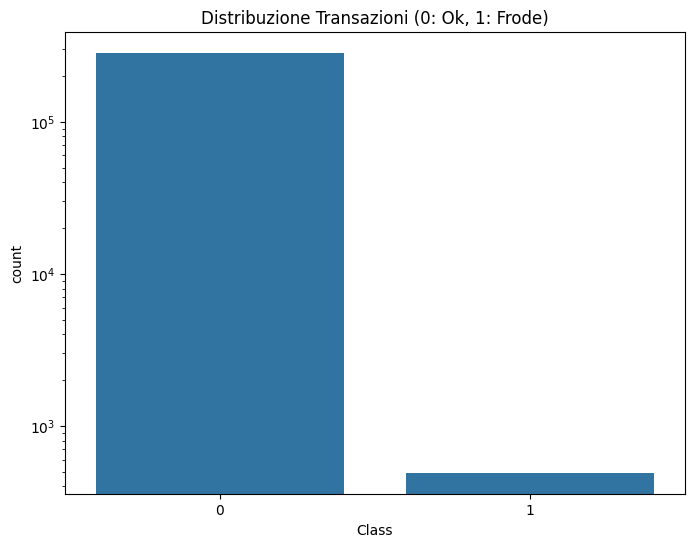

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizzazione
plt.figure(figsize=(8, 6))
sns.countplot(x='Class', data=df)
plt.title('Distribuzione Transazioni (0: Ok, 1: Frode)')
plt.yscale('log') # Indispensabile per vedere le frodi
plt.show()